# <span style="color:green"> Numerical Simulation Laboratory (NSL) </span>
## <span style="color:blue">  Numerical exercises 8 - Variational Quantum MonteCarlo</span> 


The variational principle in Quantum Mechanics states that the expectation value of the Hamiltonian over a (good) trial quantum state has the ground state energy $E_0$ as lower bound (also known as Ritz variational principle):

$$
\langle {\hat H} \rangle_T = 
\frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}
{\int dx |\Psi_T(x)|^2} \ge E_0 =
\frac{\langle \Psi_0| {\hat H} | \Psi_0 \rangle}
{\langle \Psi_0 | \Psi_0 \rangle}
$$

During this exercise you will variationally optimize the ground state of a single quantum particle in a one dimensional (1D) space confined by the following external potential:
$$
V(x) = x^4 - \frac{5}{2}x^2
$$

This 1D quantum model is not analytically solvable and should be attacked by numerical methods. In order to obtain an approximate wave function for the ground state, the Variational Monte Carlo method uses a trial wave function, parametrized by a set of variational parameters. An approximate model for the ground state wave function is the following trial wave function:
$$
\Psi_T^{\sigma,\mu}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}}+
                               e^{-\frac{(x+\mu)^2}{2\sigma^2}}
$$

$\Psi_T^{\sigma,\mu}(x)$ depends on <span style="color:red">two variational parameters: $\sigma$ and $\mu$</span>.

### Exercise 08.1

Write a Variational Monte Carlo code for a single quantum particle in 1D which exploits the Metropolis algorithm to sample the square modulus of our trial wave function $|\Psi_T^{\sigma,\mu}(x)|^2$ using an uniform transition probability $T(x_{new}|x_{old})$. By using data blocking, the code should be able to compute the expectation value for the Hamiltonian

$$
\langle {\hat H} \rangle_T = 
\frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}
{\int dx |\Psi_T(x)|^2} = 
\int dx \frac{|\Psi_T(x)|^2}{\int dx |\Psi_T(x)|^2} \frac{{\hat H} \Psi_T(x)}{\Psi_T(x)}
$$

which can be used to find the parameters that minimize this quantity. Use $\hbar = 1$ and $m=1$.
<span style="color:red">Note that to measure $\langle {\hat H} \rangle_T$ you need the analytical calculation of:</span>
    
$$
\frac{{-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}} \Psi_T^{\sigma,\mu}(x)}{\Psi_T^{\sigma,\mu}(x)} 
$$

### Exercise 08.2

To find the parameters $\sigma$ and $\mu$ which minimize $\langle {\hat H} \rangle_T$, extend your Variational Monte Carlo code to face the variational optimization problem via a <span style="color:red">Simulated Annealing (SA) algorithm</span>.

Choose an appropriate starting temperature for your SA algorithm and an appropriate temperature-update-law to make the optimization work.

Compute $\langle {\hat H} \rangle_T$ with enough statistics in order to be able to measure the lowering of $\langle {\hat H} \rangle_T$ once the variational parameters are moved.

- <span style="color:red">Show a picture of $\langle {\hat H} \rangle_T$ (with statistical uncertainties) as a function of the SA steps of the algorithm</span>
- you could also show a picture of the trajectory of the SA algorithm in the variational parameter space as a function of the SA steps
- <span style="color:red">show a picture of the estimation of $\langle {\hat H} \rangle_T$ </span> and its statistical uncertainty as a function of the number of blocks/MC steps <span style="color:red">for the set of parameters which minimize $\langle {\hat H} \rangle_T$</span>
- <span style="color:red">show also a picture **of the sampled** $|\Psi_T(x)|^2$</span> by filling a histogram with the sampled configurations, moreover compare it with the analytic curve of $|\Psi_T(x)|^2$ and with the numerical solution obtained by transforming the Schrodinger equation into a matrix equation (see below the supplementary material).

### <span style="color:green">Supplementary material</span>

How can we describe a wave function as a vector? We set up a lattice of discrete points, spaced by a constant distance $dx$, and record the value of the function at each lattice point. In this way the wave function, $\Psi(x)$ become a vector:

$$
\Psi(x) \to \left[ \Psi(x_1), \Psi(x_2), ..., \Psi(x_N) \right] = 
\left[ \Psi_1, \Psi_2, ..., \Psi_N \right]
$$

The time independent Schrodinger equation 

$$
{\hat H} \Psi(x) = \left( -\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2} + V(x) \right) \Psi(x) = E \Psi(x)
$$

can be written in matrix form. But how do we write the second derivative at a particular point? Let's start with the first derivatives:
$$
\frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i+1})/2\right) \simeq \frac{\Psi_{i+1}-\Psi_{i}}{dx}\\
\frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i-1})/2\right) \simeq \frac{\Psi_{i}-\Psi_{i-1}}{dx}
$$

Thus, we can discretize the second derivative in the following way:
$$
\frac{\partial^2}{\partial x^2} \Psi(x=x_i) =
\frac{\frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i+1})/2\right) - \frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i-1})/2\right)}{dx} =
\frac{\Psi_{i+1}-2\Psi_{i}+\Psi_{i-1}}{dx^2}
$$

We finally obtain:

$$
\begin{bmatrix}
 \frac{\hbar^2}{m\,dx^2}+V(x_1)& -\frac{\hbar^2}{2m\,dx^2} & 0 & \dots  & 0 \\
-\frac{\hbar^2}{2m\,dx^2} & \frac{\hbar^2}{m\,dx^2}+V(x_2) & -\frac{\hbar^2}{2m\,dx^2} & \dots  & 0 \\
 0                        & -\frac{\hbar^2}{2m\,dx^2} & \frac{\hbar^2}{m\,dx^2}+V(x_3) & \dots  & 0 \\
 \vdots                   & \vdots                    & \vdots & \ddots & \vdots \\
 0                    & 0                & 0 & \dots  & \frac{\hbar^2}{m\,dx^2}+V(x_N)
\end{bmatrix}
\begin{bmatrix}
\Psi_{1} \\
\Psi_{2} \\
\vdots \\
\Psi_{N}
\end{bmatrix}
= E
\begin{bmatrix}
\Psi_{1} \\
\Psi_{2} \\
\vdots \\
\Psi_{N}
\end{bmatrix}
$$

To solve the time independent Schrodinger equation we therefore have to find eigenstates and eigenvalues of the matrix just obtained.

Ground state energy:  -0.4604658796926825
1st excited state energy:  0.09742471331760562
2nd excited state energy:  1.9717331343931928


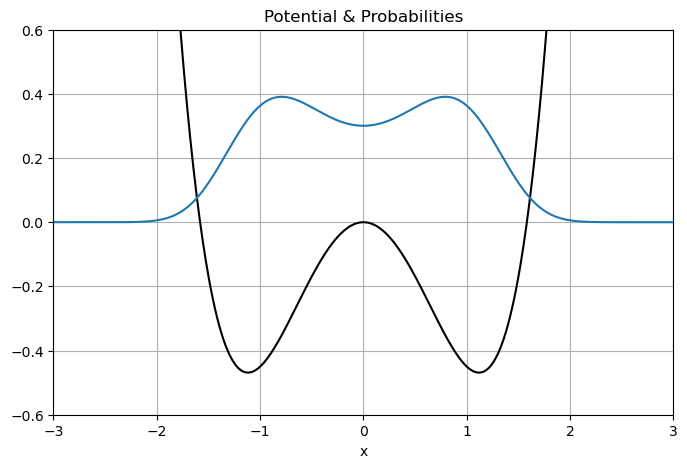

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def Vpot(x):
    return (x**2 - 2.5)*x**2
    #return 0.5*x**2

hbar = 1
m = 1
a = 10
N = 1000 # number of iterations

# Step sizes
x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

# The central differences method: f" = (f_1 - 2*f_0 + f_-1)/dx^2

CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
# np.diag(np.array,k) construct a "diagonal" matrix using the np.array
# The default is k=0. Use k>0 for diagonals above the main diagonal, 
# and k<0 for diagonals below the main diagonal

# Hamiltonian matrix
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)

# Compute eigenvectors and their eigenvalues
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)

prob_galli_GS = psi[0]**2

x_galli_gs = x

print("Ground state energy: ", E[0])
print("1st excited state energy: ", E[1])
print("2nd excited state energy: ", E[2])

# Plot a few things
plt.figure(figsize=(8,5))
scale = 0.3
plt.plot(x, scale*V, color="Black", label="Potential") # plot the potential
plt.plot(x,(psi[0])**2)
# plt.plot(x,(psi[1])**2)
# ax2.plot(x,(psi[2])**2)
plt.title("Potential & Probabilities")
plt.xlabel("x")
plt.grid(True)
plt.xlim((-3,3))
plt.ylim((-0.6,0.6))
plt.show()

## **Submission**
McMillan first introduce the problem of finding the ground state of a many body system quantum mechanics problem as an optimization problem starting from Ritz variational principal:
$\begin{equation}
    E[\psi_T] \geq E[\psi_0]
    \tag{1}
\end{equation}
$
Where $\psi_T$ is a trail wave function with fixed parameters that a trial wave function trying to reproduce the ground state wave function and $E[\cdot]$ is the energy expectation value calculated for that specific wave function.
It is possible to rewrite $E[\psi_T]$ as:
$
\begin{equation}
    E_T = \int d\mathbf{r_1}...d\mathbf{r_N}p(\mathbf{r_1}, ..., \mathbf{r_N})E_{loc}(\mathbf{r_1}, ..., \mathbf{r_N})
    \tag{2}
\end{equation}
$

Where $p(\mathbf{r_1}, ..., \mathbf{r_N})$ is the probability distribution associated to finding the particle in the position $\mathbf{r} = (\mathbf{r_1}, ..., \mathbf{r_N})$ relatively to the wave function $\psi_T(\mathbf{r_1}, ..., \mathbf{r_N})$ and $E_{loc} = \frac{\hat{H}\psi_T}{\psi_T}$ 

---
### **Exercise 8.1**

To compute ($2$) first it was necessary to calculate (we are working in a 1D case of a 1 particle system):
$
\begin{equation}
    (\hat{T} + \hat{V})\psi_T = -\frac{1}{2}\frac{\partial^2 \psi_T}{\partial x^2} + V(x) \psi_T 
\end{equation}
$
and calculate analitically the first term:
$\begin{equation}
\frac{\partial^2 \psi_T}{\partial x^2} = -\frac{1}{\sigma^2} \left[ -\left(\frac{x - \mu}{\sigma}\right)^2 e^{-\frac{1}{2}\left(\frac{x - \mu}{\sigma}\right)^2} - \left(\frac{x + \mu}{\sigma}\right)^2 e^{-\frac{1}{2}\left(\frac{x + \mu}{\sigma}\right)^2} + \psi(x) \right]
\end{equation}
$
Thus
$
\begin{equation}
    E_{loc} = -\frac{1}{2}\frac{1}{\psi_T}\frac{\partial^2 \psi_T}{\partial x^2} + V(x)
\end{equation}$
For a specific wave function with $(\sigma; \mu)$ fixed parameters. The values of $E_{loc}$ are sampled by evalutaing the values of the Hamiltonian on the spatial coordinates according to the probability density function of the trial wave function, and to do so we exploit the Metropolis sampling algorithm. 
The code for this part can be found `SOURCE/variation_mc.cpp`. I wrote a class called `variation_mc` similar to the structure of the classes of the previous exercises. To calculate the average value of the energy function after a MC step (regardless of the step being accepted or not) I implemented the function `double Variation_MC ::calculate()` and `bool Variation_MC ::metro()`. 

The transition probability $T(x_{new}|x_{old})$, where the step used to write $x_{new}$ is sampled from a uniform probability $\in [-\delta; \delta]$, is given by the Metropolis sampling:
$\begin{equation}
    T(x_{new}|x_{old}) = \min\big[\frac{p(x_{new})}{p(x_{old})}; 1\big]
\end{equation}$

:
```cpp
// Calculates <H_T>
double Variation_MC ::calculate()
{
  ofstream out;
  bool metro_result = false;
  metro_result = metro();
  _nattempts++;
  H_T = 0;
  // propose the new position from the old one
  x_new = x_old + _effective_step;
  // accept or reject the move: if accepted, update x_old to the proposed x_new
  if (metro_result == true)
  {
    x_old = x_new;
  }
  else
  {
    // rejected: keep x_old 
    x_new = x_old;
  }
  // local energy (do not multiply by acceptance)
  double kinetic = -0.5 * Laplacian(x_old) / psi(x_old);
  double potential = pow(x_old, 4.0) - 5.0 / 2.0 * pow(x_old, 2.0);
  H_T = kinetic + potential;
  this->measure();
  return H_T;
}

bool Variation_MC ::metro()
{ // Metropolis algorithm

  // reset everything
  bool decision = false;
  double p_new = 0, p_old = 0;
  acceptance = 0, _effective_step = 0;

  _effective_step = _step * _rnd.Rannyu(-1, 1);
  p_new = psi(x_old + _effective_step) * psi(x_old + _effective_step);
  p_old = psi(x_old) * psi(x_old);
  acceptance = p_new / p_old;

  // in this way x_old and x_new remain unchanged and will be changed
  // in case the move is accepted
  if (_rnd.Rannyu() < acceptance)
  {
    decision = true; // Metropolis acceptance step
    _naccepted++;
  }
  return decision;
}
```

First of all we have to fix the acceptance rate at a value not lower than $50\%$, we find that if we define $\delta = 2.5$ it yields a value of acceptance greater $50%$.

### **Exercise 08.2**

To find the parameters $\sigma$ and $\mu$ which minimize $\langle {\hat H} \rangle_T$, extend your Variational Monte Carlo code to face the variational optimization problem via a <span style="color:red">Simulated Annealing (SA) algorithm</span>.

Choose an appropriate starting temperature for your SA algorithm and an appropriate temperature-update-law to make the optimization work.

Compute $\langle {\hat H} \rangle_T$ with enough statistics in order to be able to measure the lowering of $\langle {\hat H} \rangle_T$ once the variational parameters are moved.

- <span style="color:red">Show a picture of $\langle {\hat H} \rangle_T$ (with statistical uncertainties) as a function of the SA steps of the algorithm</span>
- you could also show a picture of the trajectory of the SA algorithm in the variational parameter space as a function of the SA steps
- <span style="color:red">show a picture of the estimation of $\langle {\hat H} \rangle_T$ </span> and its statistical uncertainty as a function of the number of blocks/MC steps <span style="color:red">for the set of parameters which minimize $\langle {\hat H} \rangle_T$</span>
- <span style="color:red">show also a picture **of the sampled** $|\Psi_T(x)|^2$</span> by filling a histogram with the sampled configurations, moreover compare it with the analytic curve of $|\Psi_T(x)|^2$ and with the numerical solution obtained by transforming the Schrodinger equation into a matrix equation (see below the supplementary material).

--- 
#### **Simulated annealing**
Simulated annealing is an metaheuristic optimization technique that takes inspiration from the slow freezing of liquids or gasses. The definition of annealing is the slow freezing of something in order that when freezing the particles that make up the object arrange themselves in a way to minimize che free energy of the system. This optimization technique works very similarly by lowering slowly the "statistical temperature" relative to the Boltzmann weight:
$$
p(\mathbf{x}) = exp(-\beta (L(\mathbf{x})))
$$
and finding the points in the configuration space that yield local or even global minimum values of the loss/cost function $L(\mathbf{x})$. Therefore one calculates the value of $L(\mathbf{x})$ $n$ times and averages over these times, one then finds $L(\mathbf{x'})$ and to calculate the transition probability from the state $\mathbf{x}$ to $\mathbf{x'}$ we use the Metropolis algorithm:

$$
P = 
\begin{cases} 
e^{-\beta(L(\vec{x}')-L(\vec{x}))} & \text{if } L(\vec{x}') > L(\vec{x}) \\ 
1 & \text{otherwise} 
\end{cases}
$$

where $\beta$ is the fictitious inverse temperature.


A consequence of this is that for high temperature ($\beta \to 0$) states where $L(\mathbf{x'}) > L(\mathbf{x})$ are easily accepted, which means that for high temperature the configuration space is explored widely. On the other hand for low temperatures ($\beta \to \infty$) transitions with $L(\mathbf{x'}) > L(\mathbf{x})$ are almost never excepted. Lowering the temperature therefore narrows the range of explorable point of the configuration space. If the decrease happens very slowly then there is a possiblity that the final state $\mathbf{x}$ of being the ground state or a local minimum with a very low energy value. 

In the simulation below it is interesting to observe that simulations with slower SA present values of $<H_T>$ smaller than ones with faster annealings. 

Generazione grafici per SA1...


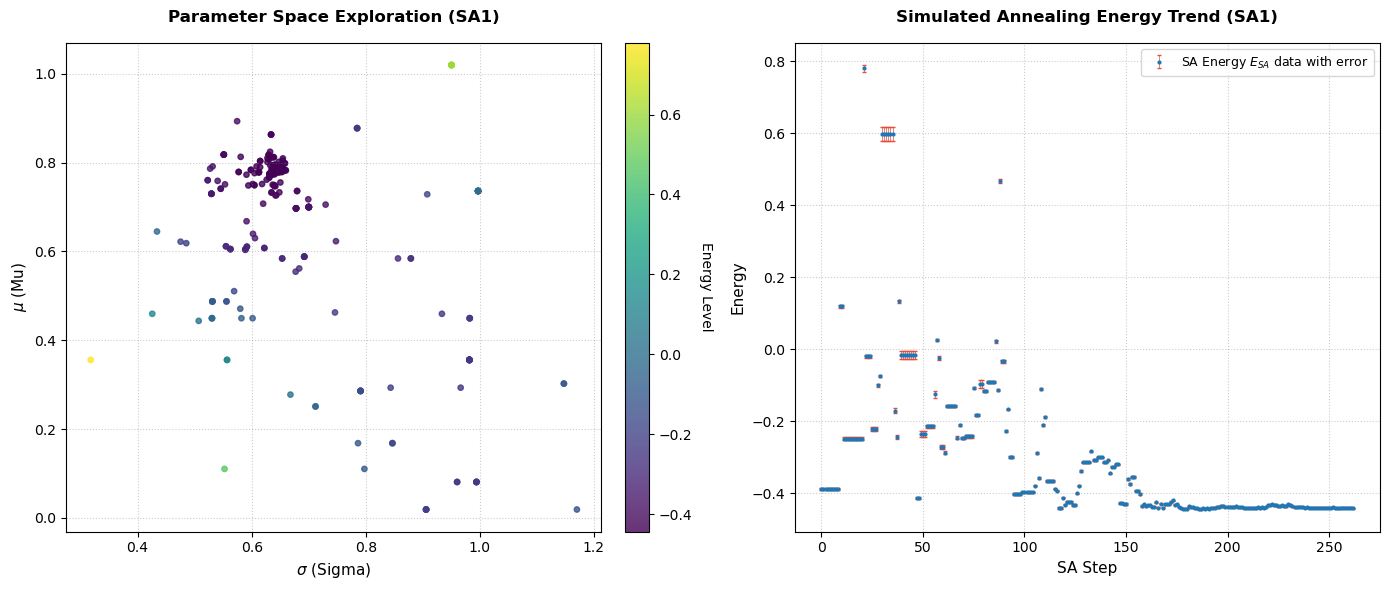

Generazione grafici per SA2...


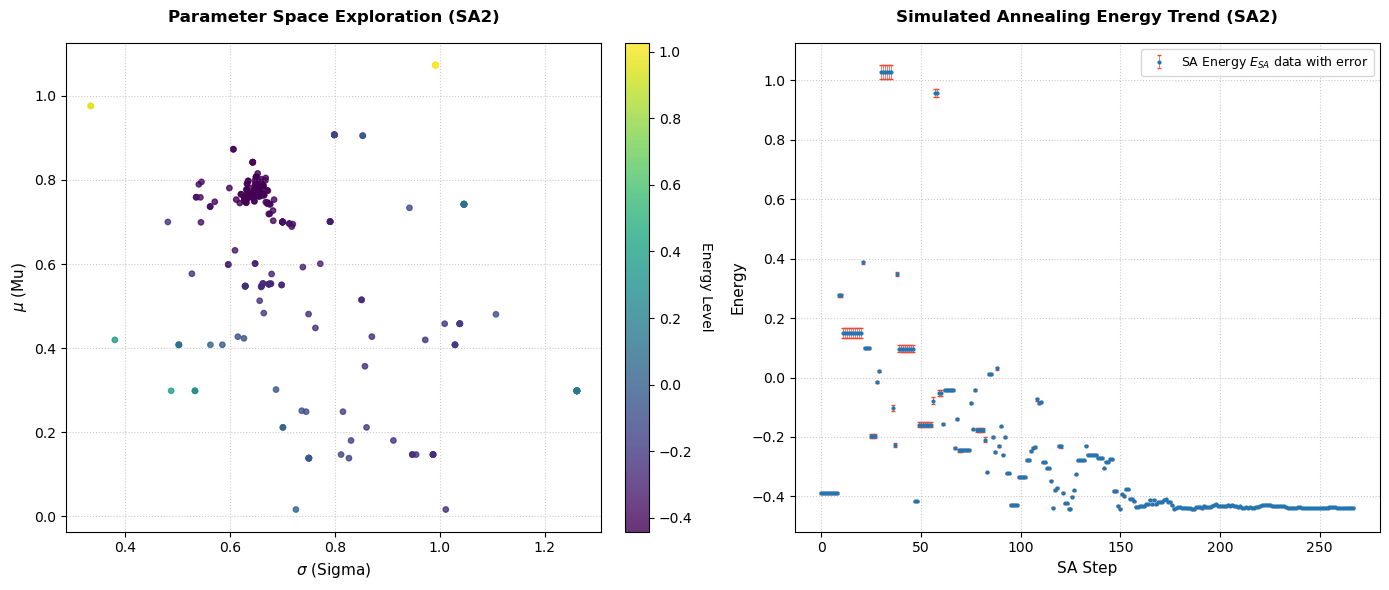

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_sa_results(folder_name):
    # Crea la cartella Images se non esiste
    if not os.path.exists('IMAGES'):
        os.makedirs('IMAGES')

    # Costruisci il percorso dinamico al file in base alla cartella (SA1, SA2, SA3)
    data_path = f'OUTPUT/{folder_name}/energy_sigma_mu.dat'
    
    # Controllo di sicurezza nel caso il file non esista
    if not os.path.exists(data_path):
        print(f"Attenzione: Il file {data_path} non esiste. Salto questa cartella.")
        return

    print(f"Generazione grafici per {folder_name}...")

    # 1. CARICAMENTO DATI
    data = np.loadtxt(data_path)
    step = data[:, 0]
    energy = data[:, 1]
    err_energy = data[:, 2]
    mu = data[:, 3]
    sigma = data[:, 4]

    # 2. CONFIGURAZIONE LAYOUT
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor('white')

    # ----------------------------------------------------------------------
    # SUBPLOT 1 (SINISTRA): Scatter Plot 2D colorato in base all'energia
    # ----------------------------------------------------------------------
    scatter2d = ax1.scatter(sigma, mu, c=energy, cmap='viridis', s=15, alpha=0.8)

    ax1.set_title(f'Parameter Space Exploration ({folder_name})', fontsize=12, fontweight='bold', pad=15)
    ax1.set_xlabel(r'$\sigma$ (Sigma)', fontsize=11)
    ax1.set_ylabel(r'$\mu$ (Mu)', fontsize=11)
    ax1.set_facecolor('white')
    ax1.grid(True, linestyle=':', alpha=0.4, color='gray')

    cbar = plt.colorbar(scatter2d, ax=ax1, fraction=0.046, pad=0.04)
    cbar.set_label('Energy Level', rotation=270, labelpad=15)

    # ----------------------------------------------------------------------
    # SUBPLOT 2 (DESTRA): Andamento Energia SA con Barre d'Errore
    # ----------------------------------------------------------------------
    ax2.errorbar(
        step, energy, yerr=err_energy, 
        fmt='o',            
        markersize=2,       
        color='#1f77b4',    
        ecolor='#e74c3c',   
        elinewidth=0.5,     
        capsize=1.5,        
        label='SA Energy $E_{SA}$ data with error'
    )

    ax2.set_title(f'Simulated Annealing Energy Trend ({folder_name})', fontsize=12, fontweight='bold', pad=15)
    ax2.set_xlabel('SA Step', fontsize=11)
    ax2.set_ylabel('Energy', fontsize=11)
    ax2.set_facecolor('white')
    ax2.grid(True, linestyle=':', alpha=0.4, color='gray')
    ax2.legend(loc='best', fontsize=9)

    plt.tight_layout()
    
    # Salva con un nome dinamico in base alla cartella
    save_path = f"IMAGES/energy_sigma_mu_scatter_{folder_name}.png"
    plt.savefig(save_path, dpi=300) 
    plt.show()
    
    # Chiude la figura per liberare memoria prima del ciclo successivo
    plt.close(fig) 


# --- ESECUZIONE DEL CODICE ---
# Lista delle cartelle da analizzare
folders_to_analyze = ["SA1", "SA2"]

# Ciclo for per ripetere l'analisi per ogni configurazione
for folder in folders_to_analyze:
    plot_sa_results(folder)

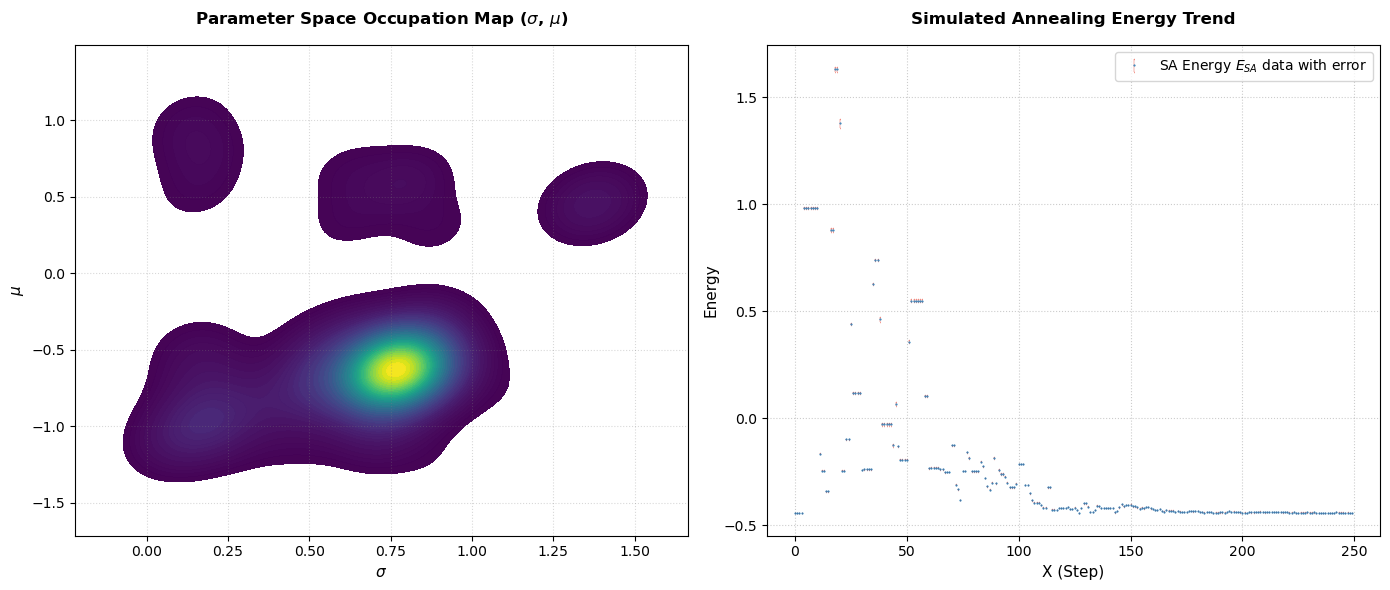

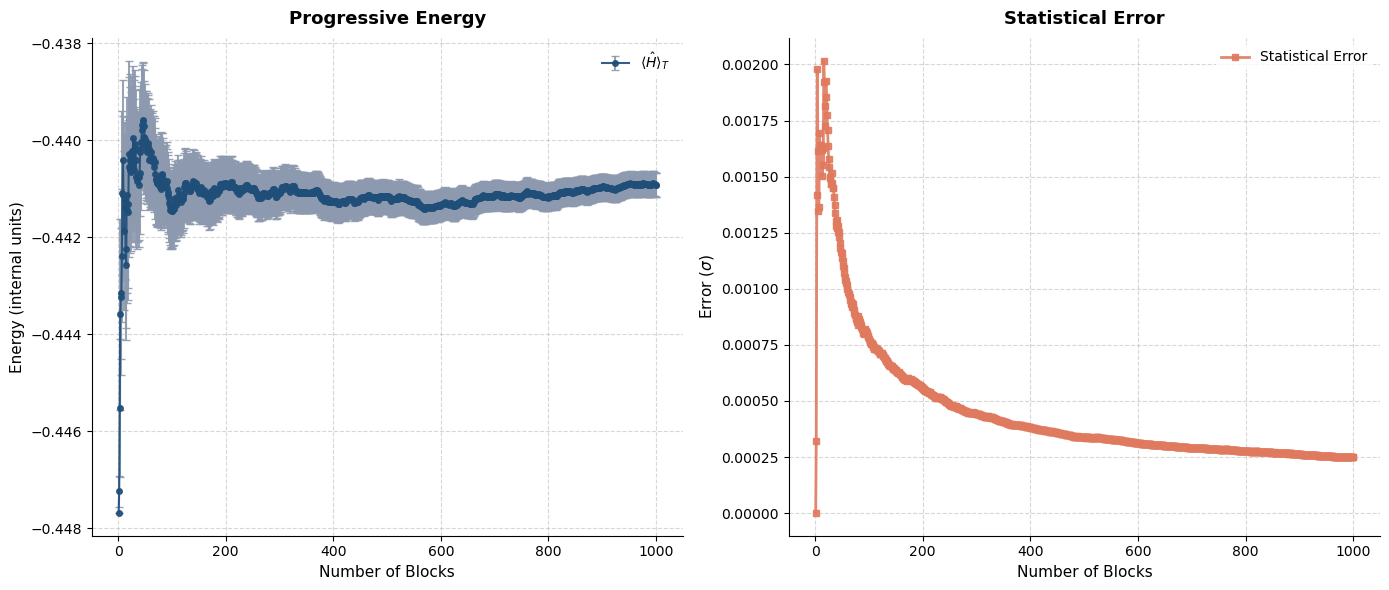

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. DATA LOADING
# File 1: Sigma and mu parameters
data_sm1 = np.loadtxt('OUTPUT/SA3/sigma_mu.dat')
sigma = data_sm1[:, 1]
mu = data_sm1[:, 2]

# File 2: Energy and relative errors
data_en2 = np.loadtxt('OUTPUT/SA3/energySA.dat')
x_en = data_en2[:, 0]
y_en = data_en2[:, 1]
y_err = data_en2[:, 2]

# 2. LAYOUT CONFIGURATION (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white') # External white background

# ----------------------------------------------------------------------
# SUBPLOT 1 (LEFT): Clean heatmap on a white background
# ----------------------------------------------------------------------
# We use sns.kdeplot to create a smooth trace. 
# 'thresh=0.05' ensures that where the density is almost zero, the background remains pure white.
sns.kdeplot(
    x=sigma, y=mu, 
    ax=ax1, 
    cmap="viridis",     # Colormap (you can use "Reds", "Purples", "viridis", etc.)
    fill=True,          # Fills the density levels
    thresh=0.05,        # Hides the background of the map, keeping it white
    levels=40,          # High precision of the trace
    alpha=0.99
)

ax1.set_title(r'Parameter Space Occupation Map ($\sigma$, $\mu$)', fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel(r'$\sigma$', fontsize=11)
ax1.set_ylabel(r'$\mu$', fontsize=11)
ax1.set_facecolor('white') # White plot background
ax1.grid(True, linestyle=':', alpha=0.3, color='gray') # Very light reference grid

# ----------------------------------------------------------------------
# SUBPLOT 2 (RIGHT): X-Y Plot with Error Bars
# ----------------------------------------------------------------------
ax2.errorbar(
    x_en, y_en, yerr=y_err, 
    fmt='o',            # Circle markers for the points
    markersize=0.5,
    color='#1f77b4',    # Consistent point color
    ecolor='#e74c3c',   # Red error bars to make them stand out clearly
    elinewidth=0.3,     # Error line thickness
    capsize=0.2,        # Horizontal caps at the ends of the error bars
    label='SA Energy $E_{SA}$ data with error',
)

ax2.set_title('Simulated Annealing Energy Trend', fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel('X (Step)', fontsize=11)
ax2.set_ylabel('Energy', fontsize=11)
ax2.set_facecolor('white')
ax2.grid(True, linestyle=':', alpha=0.4, color='gray')
ax2.legend(loc='best')

# Optimize spacing between plots
plt.tight_layout()
plt.savefig("IMAGES/energy_sigma_mu3.png", dpi=300) # Save the figure at high resolution
plt.show()


color_energy = '#1F4E79'  # Blu notte profondo
color_error = '#E07A5F'   # Corallo/Arancio opaco
color_accent = '#8D99AE'  # Grigio/Azzurro per dettagli (es. barre errore)

# Caricamento dati
data = np.loadtxt('OUTPUT/ENERGY/energyBEST.dat')

# Colonne
x = data[:, 0]      # Blocchi / Passi
y = data[:, 2]      # Energia progressiva
yerr = data[:, 3]   # Errore progressivo

# Creazione della figura con 1 riga e 2 colonne
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# -----------------------------------------------------------------------------
# GRAFICO 1 (SINISTRA): ENERGIA CON BARRE DI ERRORE
# -----------------------------------------------------------------------------
ax1.errorbar(
    x,
    y,
    yerr=yerr,
    color=color_energy,
    ecolor=color_accent,
    linestyle='-',
    linewidth=1.5,
    marker='o',
    markersize=4,
    capsize=3,
    alpha=0.9,
    label=r'$\langle \hat{H} \rangle_T$'
)

ax1.set_title('Progressive Energy', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Number of Blocks', fontsize=11)
ax1.set_ylabel('Energy (internal units)', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.legend(frameon=True, facecolor='white', edgecolor='none')

# -----------------------------------------------------------------------------
# GRAFICO 2 (DESTRA): ANDAMENTO DELL'ERRORE STATISTICO
# -----------------------------------------------------------------------------
ax2.plot(
    x,
    yerr,
    color=color_error,
    linestyle='-',
    linewidth=2,
    marker='s',
    markersize=4,
    alpha=0.9,
    label='Statistical Error'
)

ax2.set_title('Statistical Error', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Number of Blocks', fontsize=11)
ax2.set_ylabel('Error ($\sigma$)', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(frameon=True, facecolor='white', edgecolor='none')

# Oltre all'estetica, per l'errore è utile vedere il decadimento tipico 1/sqrt(N)
# Se vuoi una scala logaritmica sull'asse y dell'errore (opzionale, basta scommentare):
# ax2.set_yscale('log')
plt.tight_layout()
plt.savefig("IMAGES/best_energy_datablocking.png")
plt.show()

#### **Description of the simulation and comment**

The two plots were obtained from two different simulations. The first plot corresponds to a simulation with initial temperature $T_i = 3.0$, final temperature $T_f = 0.001$, and cooling rate $\alpha = 0.97$ ($\alpha$ being the scaling factor used to reduce the temperature at each Simulated Annealing cycle). This simulation took 262 cycles, with a number of accepted moves $N_{acc} = 151$. For the second plot, the simulation parameters were $T_i = 3.5$, $T_f = 0.001$, and $\alpha = 0.97$. This simulation required 267 cycles and yielded $N_{acc} = 155$. Both simulations started with the initial parameters $\sigma = 0.7$ and $\mu = 0.7$.

As can be seen, the energy initially fluctuates significantly. The plateaus in the plot correspond to rejected configurations where the new $\sigma$ and $\mu$ parameters were not accepted. At each cycle, the trial parameters ($\sigma$, $\mu$) are generated by adding a random step to the previous values, sampled from a Gaussian distribution with zero mean and variance equal to $T$. Negative values for the parameters are rejected because the physics of this specific problem is degenerate with respect to the sign inversion of $\sigma$ and $\mu$. 

During the initial cycles, at high temperatures, the parameters are freer to explore the phase space. Furthermore, the Metropolis algorithm accepts a larger number of moves in this regime, meaning that even steps leading to an increase in energy have a higher probability of being accepted compared to lower temperatures. Each energy value was computed using the data blocking method with $N_{blocks} = 100$ and $N_{steps} = 3000$. For each SA step, I recorded the cumulative average energy and its associated statistical error for the given trial wave function $\psi_T$.

When running the simulation, it is crucial to carefully tune the initial temperature and the cooling rate $\alpha$. If the system is quenched too rapidly, there is a significant risk that it becomes trapped in a local minimum.

A final simulation was performed with $T_i = 2.0$, $T_f = 0.001$, and $\alpha = 0.997$, taking a total of $N_{cycles} = 249$ cycles with $N_{acc} = 169$. This run yielded the lowest energy value, thus providing the optimal parameters ($\sigma_{best}$, $\mu_{best}$). From this, we conclude that cooling the system more slowly allows the simulation to explore the $(\sigma, \mu)$ parameter space more thoroughly, successfully converging to the optimal configuration ($\sigma_{best}$, $\mu_{best}$).



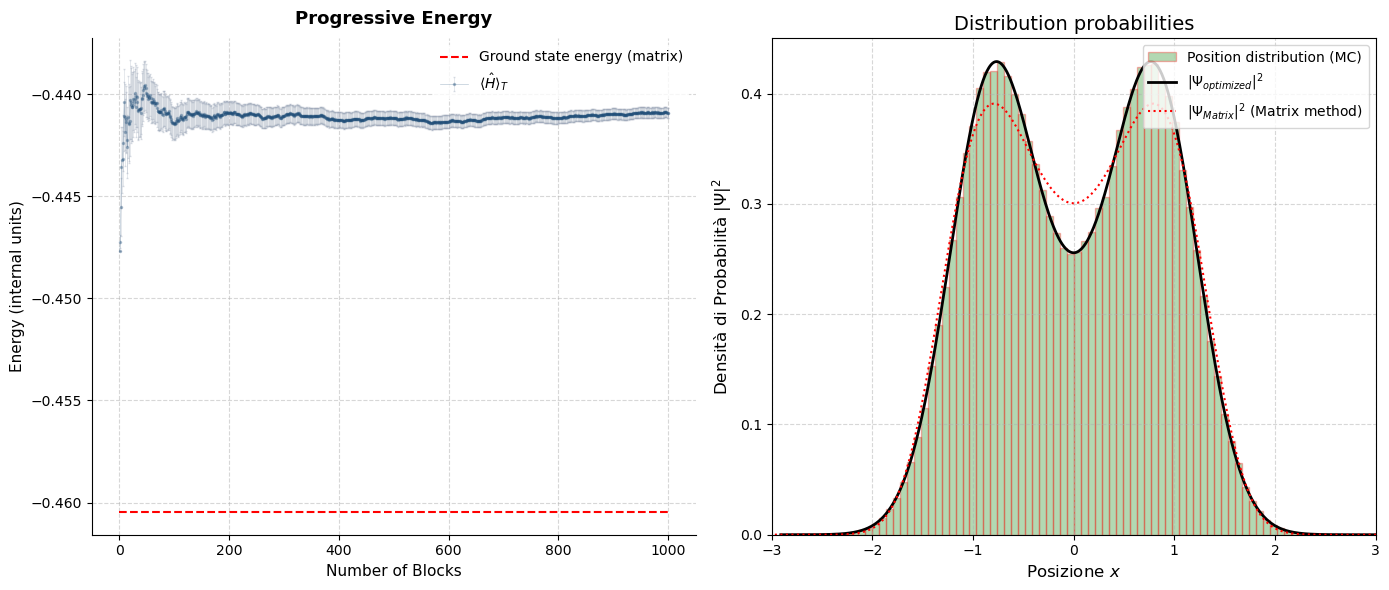

In [21]:
color_energy = '#1F4E79'  # Blu notte profondo
color_error = '#E07A5F'   # Corallo/Arancio opaco
color_accent = '#8D99AE'  # Grigio/Azzurro per dettagli (es. barre errore)

# Caricamento dati
data = np.loadtxt('OUTPUT/ENERGY/energyBEST.dat')

# Colonne
x = data[:, 0]      # Blocchi / Passi
y = data[:, 2]      # Energia progressiva
yerr = data[:, 3]   # Errore progressivo

# Creazione della figura con 1 riga e 2 colonne
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

x_max = x.max()

# -----------------------------------------------------------------------------
# GRAFICO 1 (SINISTRA): ENERGIA CON BARRE DI ERRORE
# -----------------------------------------------------------------------------
ax1.errorbar(
    x,
    y,
    yerr=yerr,
    color=color_energy,
    ecolor=color_accent,
    linestyle='-',
    linewidth=0.5,
    marker='o',
    markersize=1.5,
    capsize=0.7,
    alpha=0.3,
    label=r'$\langle \hat{H} \rangle_T$'
)

ax1.set_title('Progressive Energy', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Number of Blocks', fontsize=11)
ax1.set_ylabel('Energy (internal units)', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.hlines(y=E[0], xmin=0, xmax=x_max, color='red', linestyle='--', label='Ground state energy (matrix)')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.legend(frameon=True, facecolor='white', edgecolor='none')

# This will only read the first 10,000 data rows and ignore everything after
dati = np.loadtxt('OUTPUT/HIST/histoBEST.dat', skiprows=1, usecols=0)
dati = dati.flatten()


ax2.hist(
    dati, 
    bins=80, 
    density=True,       
    color='green',      
    alpha=0.3,          
    edgecolor='red',  
    label='Position distribution (MC)'
)

mu = 0.815528
sigma = 0.599612

# [Assicurati che x_teorica sia definita nel tuo script, 
# se non lo è, scommenta la linea qui sotto:]
# x_teorica = x_prof 

xmin, xmax = ax2.get_xlim()
x_teorica = np.linspace(xmin, xmax, 1000) # 1000 punti per una curva fluida

# 1. Calcolo della tua funzione d'onda Psi(x) analitica
psi_t = np.exp(-(x_teorica - mu)**2 / (2 * sigma**2)) + np.exp(-(x_teorica + mu)**2 / (2 * sigma**2))

# 2. Modulo quadro della tua teorica
prob_density = psi_t**2

# 3. Normalizzazione della tua curva
area = np.trapezoid(prob_density, x_teorica)
prob_density_norm = prob_density / area

ax2.plot(
    x_teorica, prob_density_norm, 
    color='black',      
    linewidth=2, 
    label=r'$|\Psi_{optimized}|^2$ '
)

ax2.plot(
    x_galli_gs, prob_galli_GS, 
    color='red',      
    linewidth=1.5,
    linestyle=':', # Puntinata per vedere le differenze millimetriche
    label=r'$|\Psi_{Matrix}|^2$ (Matrix method)'
)

# ABBELLIMENTO
ax2.set_title('Distribution probabilities', fontsize=14)
ax2.set_xlabel('Posizione $x$', fontsize=12)
ax2.set_ylabel('Densità di Probabilità $|\Psi|^2$', fontsize=12)

# Limitiamo l'asse x per zoomare sulla zona di interesse (es. tra -3 e 3 come il prof)
ax2.set_xlim((-3, 3)) 

ax2.grid(linestyle='--', alpha=0.5)
ax2.legend(loc='upper right')

plt.savefig("IMAGES/hist_plot.png")
plt.tight_layout()
plt.show()

The values were computed using $N_{blocks} = 1000$ and $N_{steps} = 10^4$, whereas for the plot on the right, a single block of $10^6$ steps was used. It can be observed that the analytical probability density function, plotted using the optimized parameters ($\mu = 0.815528$, $\sigma = 0.599612$), fits well with the empirical probability distribution obtained by sampling the spatial coordinates $x$ of the particle during the Metropolis algorithm. Furthermore, comparing these distributions with the one obtained via the matrix method reveals a good agreement.